# Tutorial – Session 3

## Diskrete fordelinger II: Hypergeometrisk, Geometrisk, Negativ binomial og Poisson
### Teori, Python (SciPy) og WolframAlpha

I denne tutorial udvider vi paletten af diskrete fordelinger fra Session 2. Vi arbejder systematisk med fire nye fordelinger:

1. **Hypergeometrisk** – stikprøvetagning *uden* tilbagelægning
2. **Geometrisk** – antal forsøg indtil første succes
3. **Negativ binomial** – antal forsøg indtil $r$-te succes
4. **Poisson** – antal hændelser i et tidsrum eller område

Vi lærer at beregne **PMF**, **CDF**, **Middelværdi (Expected Value)** og **Varians** i Python, og afslutter med **simulation** af alle fire fordelinger.

---

## 1. Begreber: PMF og CDF

Som i Session 2 bruger vi:

| Begreb | Forkortelse | Matematisk | Spørgsmål |
| :--- | :--- | :--- | :--- |
| **PMF** | Probability Mass Function | $P(X = k)$ | Hvad er sandsynligheden for **præcis** $k$? |
| **CDF** | Cumulative Distribution Function | $P(X \leq k)$ | Hvad er sandsynligheden for **$k$ eller mindre**? |

---

## 2. Python Setup

Vi bruger `scipy.stats` til fordelingerne.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, geom, nbinom, poisson

# hypergeom = Hypergeometrisk fordeling
# geom     = Geometrisk fordeling
# nbinom   = Negativ binomialfordeling
# poisson  = Poisson-fordeling

---

## 3. Hypergeometrisk Fordeling

### 3.1 Teori

Den **hypergeometriske fordeling** beskriver situationer med **stikprøvetagning uden tilbagelægning**. Tænk på en urne med $M$ kugler: $n$ af dem er "succes" (f.eks. defekte), resten er "fiasko". Vi trækker $N$ kugler uden at lægge dem tilbage. $X$ er antallet af succes-kugler blandt de $N$ trukne.

**Parametre:**
- $M$ = populationens størrelse (antal kugler i alt)
- $n$ = antal "succes"-elementer i populationen
- $N$ = antal trækninger (stikprøvestørrelse)

**PMF:**
$$P(X=k) = \frac{\binom{n}{k} \binom{M-n}{N-k}}{\binom{M}{N}}$$

**Middelværdi (Expected Value):** $E[X] = N \cdot \frac{n}{M}$

**Varians:** $\text{Var}(X) = N \cdot \frac{n}{M} \cdot \frac{M-n}{M} \cdot \frac{M-N}{M-1}$

In [2]:
M, n, N = 20, 7, 12   # 20 kugler, 7 succeser, vi trækker 12

# Objekt-metode
X = hypergeom(M, n, N)
print(f"P(X=4): {X.pmf(4):.4f}")
print(f"P(X<=4): {X.cdf(4):.4f}")

# Direkte
print(f"Mean: {hypergeom.mean(M, n, N):.4f}, Var: {hypergeom.var(M, n, N):.4f}")

P(X=4): 0.3576
P(X<=4): 0.6084
Mean: 4.2000, Var: 1.1495


### 3.3 WolframAlpha

**OBS:** WolframAlpha bruger parameterrækkefølgen (antal trækninger, antal succeser i populationen, populationens størrelse), dvs. $(N, n, M)$. For vores eksempel $(M{=}20, n{=}7, N{=}12)$ bliver det altså $(12, 7, 20)$.

- **PMF $P(X=4)$**:

```
P(X=4) HypergeometricDistribution(12, 7, 20)
```

- **CDF $P(X \leq 4)$**:

```
P(X<=4) HypergeometricDistribution(12, 7, 20)
```

- **Survival function** (1 − CDF):

```
P(X>4) HypergeometricDistribution(12, 7, 20)
```

- **Middelværdi (Expected Value)**:

```
mean HypergeometricDistribution(12, 7, 20)
```

- **Varians**:

```
variance HypergeometricDistribution(12, 7, 20)
```

- **Standardafvigelse**:

```
standard deviation HypergeometricDistribution(12, 7, 20)
```

---

## 4. Geometrisk Fordeling

### 4.1 Teori

Den **geometriske fordeling** beskriver **antallet af forsøg indtil første succes** i en serie uafhængige Bernoulli-forsøg. Eksempel: Hvor mange terningekast før vi får en 6'er?

**Parametre:**
- $p$ = sandsynlighed for succes i hvert forsøg

**PMF:** (for $k = 1, 2, 3, \ldots$)
$$P(X=k) = (1-p)^{k-1} \cdot p$$

**Middelværdi (Expected Value):** $E[X] = \frac{1}{p}$

**Varians:** $\text{Var}(X) = \frac{1-p}{p^2}$

In [3]:
p = 0.2   # 20% chance for succes pr. forsøg

X = geom(p)
print(f"P(X=3): {X.pmf(3):.4f}")      # Første succes i 3. forsøg
print(f"P(X<=5): {X.cdf(5):.4f}")
print(f"Mean: {X.mean():.4f}, Var: {X.var():.4f}")

P(X=3): 0.1280
P(X<=5): 0.6723
Mean: 5.0000, Var: 20.0000


### 4.3 WolframAlpha

**OBS:** WolframAlphas `GeometricDistribution` tæller antal **fiaskoer** før første succes. For "første succes i 3. forsøg" = 2 fiaskoer før succes, brug $P(X=2)$.

- **PMF**:

```
P(X=2) GeometricDistribution(0.2)
```

- **CDF $P(X \leq 4)$**:

```
P(X<=4) GeometricDistribution(0.2)
```

- **Survival function** (1 − CDF):

```
P(X>4) GeometricDistribution(0.2)
```

- **Middelværdi (Expected Value)**:

```
mean GeometricDistribution(0.2)
```

- **Varians**:

```
variance GeometricDistribution(0.2)
```

- **Standardafvigelse**:

```
standard deviation GeometricDistribution(0.2)
```

---

## 5. Negativ Binomialfordeling

### 5.1 Teori

Den **negative binomialfordeling** generaliserer den geometriske: den beskriver **antallet af forsøg (eller fiaskoer) indtil $r$-te succes**. I SciPy tæller vi antal **fiaskoer** før $r$ succeser. Total antal forsøg = $X + r$.

**Parametre:**
- $r$ (eller $n$ i SciPy) = antal succeser, vi venter på
- $p$ = sandsynlighed for succes i hvert forsøg

**PMF:** (for $k = 0, 1, 2, \ldots$ antal fiaskoer)
$$P(X=k) = \binom{k+r-1}{r-1} \, p^r \, (1-p)^k$$

**Middelværdi (Expected Value):** $E[X] = r \cdot \frac{1-p}{p}$ (antal fiaskoer)

**Varians:** $\text{Var}(X) = r \cdot \frac{1-p}{p^2}$

**OBS - vær ekstra forsigtig med parametrene (det er her mange bytter rundt):**

- `r` = antal **succeser** du venter på (ikke antal forsøg)
- `p` = sandsynlighed for **succes** i hvert forsøg (ikke fejl-sandsynligheden)
- `X` = antal **fiaskoer** før den $r$-te succes
- Samlet antal forsøg = $X + r$

Huskeregel: Hvis en opgave siger "4. succes på kald nummer 12", så er det **8 fiaskoer forinden**. Dvs. i modellen bruger du $X=8$, $r=4$, $p=0.30$.

In [ ]:
r, p = 3, 0.4   # Vent på 3 succeser, p=0.4

print(f"P(X=2): {nbinom.pmf(2, r, p):.4f}")      # 2 fiaskoer før 3. succes
print(f"P(X<=4): {nbinom.cdf(4, r, p):.4f}")
print(f"Mean (fiaskoer): {nbinom.mean(r, p):.4f}, Var: {nbinom.var(r, p):.4f}")

P(X=2): 0.1382
P(X<=4): 0.5801
Mean (fiaskoer): 4.5000, Var: 11.2500


### 5.3 WolframAlpha

Parametre: (antal succeser $r$, sandsynlighed $p$). Samme parametrisering som SciPy: `NegativeBinomialDistribution(r, p)`.

Det betyder:
- 1. parameter = **successes** (`r`)
- 2. parameter = **probability of success** (`p`)
- den stokastiske variabel er stadig antal **failures** for den $r$-te succes

- **PMF $P(X=2)$**:

```
P(X=2) NegativeBinomialDistribution(3, 0.4)
```

- **CDF $P(X \leq 4)$**:

```
P(X<=4) NegativeBinomialDistribution(3, 0.4)
```

- **Survival function** (1 − CDF):

```
P(X>4) NegativeBinomialDistribution(3, 0.4)
```

- **Middelværdi (Expected Value)**:

```
mean NegativeBinomialDistribution(3, 0.4)
```

- **Varians**:

```
variance NegativeBinomialDistribution(3, 0.4)
```

- **Standardafvigelse**:

```
standard deviation NegativeBinomialDistribution(3, 0.4)
```

---

## 6. Poisson-fordelingen

### 6.1 Teori

**Poisson-fordelingen** bruges til at modellere **antallet af hændelser** i et givet tidsrum eller område, når hændelserne sker uafhængigt med en gennemsnitlig rate. Eksempler: antal pakker til en server pr. sekund, antal fejl pr. 1000 linjer kode.

**Parametre:**
- $\lambda$ (eller $\mu$) = gennemsnitligt antal hændelser i intervallet

**PMF:** (for $k = 0, 1, 2, \ldots$)
$$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

**Middelværdi (Expected Value):** $E[X] = \lambda$

**Varians:** $\text{Var}(X) = \lambda$

In [5]:
lam = 5   # Gennemsnit 5 hændelser pr. interval

X = poisson(lam)
print(f"P(X=3): {X.pmf(3):.4f}")
print(f"P(X<=4): {X.cdf(4):.4f}")
print(f"Mean: {X.mean():.4f}, Var: {X.var():.4f}")

P(X=3): 0.1404
P(X<=4): 0.4405
Mean: 5.0000, Var: 5.0000


### 6.3 WolframAlpha

Én parameter: $\lambda$ (middelværdi).

- **PMF $P(X=3)$**:

```
P(X=3) PoissonDistribution(5)
```

- **CDF $P(X \leq 4)$**:

```
P(X<=4) PoissonDistribution(5)
```

- **Survival function** (1 − CDF):

```
P(X>4) PoissonDistribution(5)
```

- **Middelværdi (Expected Value)**:

```
mean PoissonDistribution(5)
```

- **Varians**:

```
variance PoissonDistribution(5)
```

- **Standardafvigelse**:

```
standard deviation PoissonDistribution(5)
```

---

## 7. Simulation af fordelinger i Python

Som i Session 1 og 2 kan vi simulere stokastiske variable for at tjekke teorien mod empiriske data. Alle fordelinger i `scipy.stats` har metoden `rvs()` (Random Variates).

### 7.1 Hypergeometrisk

In [6]:
M, n, N = 20, 7, 12
sim = hypergeom.rvs(M, n, N, size=10000)
print(f"Teoretisk mean: {hypergeom.mean(M,n,N):.4f}")
print(f"Empirisk mean:  {np.mean(sim):.4f}")

Teoretisk mean: 4.2000
Empirisk mean:  4.1883


### 7.2 Geometrisk

In [7]:
p = 0.2
sim = geom.rvs(p, size=10000)
print(f"Teoretisk mean: {1/p:.4f}")
print(f"Empirisk mean:  {np.mean(sim):.4f}")

Teoretisk mean: 5.0000
Empirisk mean:  4.9826


### 7.3 Negativ binomial

In [8]:
r, p = 3, 0.4
sim = nbinom.rvs(r, p, size=10000)
print(f"Teoretisk mean: {nbinom.mean(r,p):.4f}")
print(f"Empirisk mean:  {np.mean(sim):.4f}")

Teoretisk mean: 4.5000
Empirisk mean:  4.5194


### 7.4 Poisson

In [9]:
lam = 5
sim = poisson.rvs(lam, size=10000)
print(f"Teoretisk mean: {lam}")
print(f"Empirisk mean:  {np.mean(sim):.4f}")

Teoretisk mean: 5
Empirisk mean:  5.0095


### 7.5 Visualisering: Simulation vs. Teori

Vi kan plotte et histogram af simulerede værdier sammen med den teoretiske PMF – ligesom i Session 2 for binomialfordelingen:

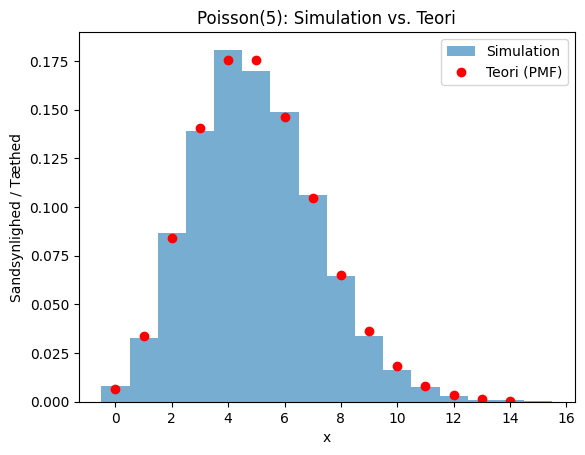

In [10]:
lam = 5
sim = poisson.rvs(lam, size=10000)
x_vals = np.arange(0, 15)
plt.hist(sim, bins=np.arange(-0.5, 16), density=True, alpha=0.6, label='Simulation')
plt.plot(x_vals, poisson.pmf(x_vals, lam), 'ro', label='Teori (PMF)')
plt.xlabel('x')
plt.ylabel('Sandsynlighed / Tæthed')
plt.legend()
plt.title('Poisson(5): Simulation vs. Teori')
plt.show()

**Hvad ser vi?** Når antallet af simulationer er højt, matcher histogrammet de teoretiske PMF-værdier. Det bekræfter, at vores model virker.

---

## 8. Opsummering – Hvad du nu skal kunne

Efter denne tutorial kan du:

- **Hypergeometrisk fordeling:** Skelne mellem stikprøvetagning med/uden tilbagelægning; beregne PMF, CDF, middelværdi og varians i Python (`hypergeom`).
- **Geometrisk fordeling:** Forstå ventetiden til første succes; beregne PMF, CDF, middelværdi og varians i Python (`geom`).
- **Negativ binomialfordeling:** Forstå ventetiden til $r$-te succes; beregne PMF, CDF, middelværdi og varians i Python (`nbinom`).
- **Poisson-fordeling:** Modellere hændelsesrater; beregne PMF, CDF, middelværdi og varians i Python (`poisson`).
- **Simulere** alle fire fordelinger i Python med `rvs()` og sammenligne empirisk fordeling med teori.